# Temperature vs Revenue — Python Data Analysis

## Objective

Analyzing the relationship between temperature and revenue using Python.

## Dataset

The dataset contains approximately 500 observations with two variables:

- Temperature
- Revenue

## Tools

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn


#### Importing Libraries


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import root_mean_squared_error

#### Importing Dataset


In [16]:
from google.colab import files

In [17]:
uploaded = files.upload()

Saving icesales.csv to icesales (1).csv


In [18]:
import os
os.listdir()

['.config', 'icesales (1).csv', 'icesales.csv', 'sample_data']

In [19]:
icesales = pd.read_csv('icesales.csv')


print(icesales)

     Temperature  Revenue
0           24.6      535
1           26.1      626
2           27.8      661
3           20.6      488
4           11.6      317
..           ...      ...
495         22.3      525
496         32.9      756
497         12.6      307
498         22.4      567
499         29.0      656

[500 rows x 2 columns]


## Exploratory Data Analysis (EDA)






In [20]:
# head

icesales.head(5) #To view top5 rows of the dataset


,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [21]:
#tail

icesales.tail(6) #To view bottom 6 rows of the dataset

,Temperature,Revenue
494,25.2,572
495,22.3,525
496,32.9,756
497,12.6,307
498,22.4,567
499,29.0,656


In [22]:
#info

icesales.info() #To check information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [23]:
#describe

icesales.describe() #To check statistical summary of the dataset



#based on below data higest revenue is 1000 while lowest is 10
# In the tempreture higest records 45 and lowest is 0

,Temperature,Revenue
count,500.000000,500.000000
mean,22.281600,522.058000
std,8.097597,175.410399
min,0.000000,10.000000
25%,17.175000,406.000000
50%,22.400000,530.000000
75%,27.800000,643.000000
max,45.000000,1000.000000


In [24]:
#shape

icesales.shape # To check number of columns and rows

(500, 2)

In [25]:
#dtype

icesales.dtypes # To check datatype of the dataset

,0
Temperature,float64
Revenue,int64


In [26]:
#isnull

icesales.isnull().sum() # To check the null values in the Dataset

,0
Temperature,0
Revenue,0


In [27]:
#duplicate

icesales.duplicated().sum() # To check the duplicate values in the Dataset

np.int64(3)

In [28]:
icesales[icesales.duplicated(keep=False)] # To view duplicte rows in the dataset



,Temperature,Revenue
55,27.4,624
73,27.4,624
148,24.7,604
162,25.5,584
246,25.5,584
270,24.7,604


In [29]:
#unique

icesales["Temperature"].unique() #To check unique values

array([24.6, 26.1, 27.8, 20.6, 11.6, 14.4, 13.8, 30.9,  1. , 31.7, 11.5,
        3.7, 18.9, 13.7, 39.6, 18.5, 26. , 42.6, 29.6, 21.8, 25.5, 15.3,
       22.7, 16.3, 23.9, 19. , 15.7, 29.2, 19.1, 35.2, 24.2,  8.8, 18.3,
       35.7, 37.1, 22.3, 17.6, 31.8, 17.1, 23.1, 18.8, 14.2, 18.7, 21. ,
       30.7, 20.5, 31.3,  6.4, 27.2, 28.7, 28. , 10.4, 27.4, 33.3, 36.6,
       12.5, 16.4, 33.6,  4. ,  6.6, 19.9, 11.7, 21.5, 12.7, 27.9, 27. ,
       28.8, 40.5, 25.6, 29.5, 16.1, 14.8, 22.2, 29.1, 29.3, 13.4, 29.4,
       30.5,  9.1,  8.6, 12.4, 20.3, 19.4, 14.7, 10. , 20. , 32.1, 14.3,
       17.7, 26.6, 17.3, 23.8, 15.6, 28.5, 24.3, 31.9, 11.1, 23. , 13. ,
       28.3, 30.6, 12.6, 16. , 26.2, 31.5, 32.3, 21.7, 19.5, 20.2,  6.1,
       22.9, 28.6, 19.8, 36.8, 19.7, 32.5, 19.3,  8.7, 24.7, 12.3, 23.4,
       21.2, 16.5, 29. , 10.3, 32.9, 32.8, 32.2, 24.8, 15.1, 23.5, 35.3,
       21.4,  9. , 26.9, 22.1, 16.2, 35.4, 11.2, 16.6, 30.4, 23.6,  9.9,
       31.6, 25.3, 24. , 10.5,  5.9,  9.8, 10.1, 22

In [30]:
#nunique

icesales["Revenue"].nunique() #To check number of unique values

344

In [31]:
# value_counts

icesales.value_counts() #To check frequent values of the dataset

Temperature  Revenue
24.7         604        2
25.5         584        2
27.4         624        2
25.6         592        1
25.8         622        1
                       ..
18.8         431        1
             422        1
             403        1
18.7         473        1
19.1         451        1
Name: count, Length: 497, dtype: int64

In [32]:
print(icesales)

     Temperature  Revenue
0           24.6      535
1           26.1      626
2           27.8      661
3           20.6      488
4           11.6      317
..           ...      ...
495         22.3      525
496         32.9      756
497         12.6      307
498         22.4      567
499         29.0      656

[500 rows x 2 columns]


### Creating 'X' and 'y' Variables for Training and Testing the Data

In [33]:
### Taking Temperature as the Independent Variable and Revenue as the Dependent Variable

xsales = icesales.iloc[:,0:1]

In [34]:
xsales

,Temperature
0,24.6
1,26.1
2,27.8
3,20.6
4,11.6
...,...
495,22.3
496,32.9
497,12.6
498,22.4


In [35]:
ysales = icesales.iloc[:, -1]

In [36]:
ysales

,Revenue
0,535
1,626
2,661
3,488
4,317
...,...
495,525
496,756
497,307
498,567


In [37]:
ysales.shape
xsales.shape

(500, 1)

### Training, Testing and splitting the data

In [38]:
x_train,x_test,y_train,y_test = train_test_split(xsales,ysales,test_size=0.3,random_state=42)

#### Creating a Simple Linear Regression Model



In [39]:
icesalesmodel = LinearRegression()

#### Fitting the model

In [40]:
icesalesmodel.fit(x_train, y_train)

LinearRegression()

#### Predicting the dataset


In [41]:
icesalespredict = icesalesmodel.predict(x_test)

In [42]:
print(icesalespredict)

[683.42932418 632.0173136  559.18363196 499.20295296 614.87997675
 304.2657462  284.98624224 314.97658174 505.62945428 685.57149128
 724.13049921 400.66326603 430.65360553 672.71848864  51.49002755
 199.29955795 522.76679114 563.46796617 584.88963725 683.42932418
 557.04146485 784.11117821 655.58115178 569.89446749 912.64120465
 666.29198732 314.97658174 632.0173136  732.69916764 698.42449393
 434.93793974 471.35478056 711.27749657 801.24851507 640.58598203
 492.77645164 745.55217029 317.11874885 261.42240406 130.75021052
 582.74747014 229.28989745 548.47279642 392.0945976  437.08010685
 593.45830567 572.0366346  124.3237092  475.63911478 531.33545957
 623.44864517 503.48728717 484.20778321 499.20295296 550.61496353
 632.0173136  574.17880171 679.14498996 171.45138556 662.0076531
 584.88963725 704.85099525 535.61979378 629.8751465  677.00282285
 411.37410156 509.91378849 494.91861874 732.69916764 312.83441463
 319.26091595 454.21744371 796.96418086 424.22710421 520.62462403
 689.855825

#### Evaluating Metrics

In [43]:
icesalesr2score = r2_score(y_test, icesalespredict)

In [44]:
icesalemae = mean_absolute_error(y_test, icesalespredict)

In [45]:
icesalesmse = mean_squared_error(y_test, icesalespredict)

In [46]:
icesalesrmse = root_mean_squared_error(y_test, icesalespredict)

R² → "How good is the overall model?"

MAE → "On average, how much is my prediction wrong?"

MSE → "How large are my errors, especially large errors?"

RMSE → "Typically, how much does my prediction differ from actual Revenue?"

| Metric       | Simple meaning                                                                      | Remember it as                |
| ------------ | ----------------------------------------------------------------------------------- | ----------------------------- |
| **R² Score** | Tells us **how well the model explains the data**.                                  | **Overall model performance** |
| **MAE**      | Tells us **on average, how much our prediction is wrong**.                          | **Average error**             |
| **MSE**      | Tells us the **average squared error**. Large errors are punished more.             | **Squared error**             |
| **RMSE**     | Tells us the **typical size of the prediction error**, in the same unit as Revenue. | **Typical error**             |


In [47]:
icesalesr2score

0.9799112633959458

In [48]:
icesalemae

18.860398569865442

In [49]:
icesalesmse

591.3065379814536

In [50]:
icesalesrmse

24.31679538881416

R² Score = 0.97

The model found a very strong relationship between Temperature and Revenue.

MAE = 18.86

The model's predictions are off by about 19 Revenue units on average.

MSE = 591.30

The average squared prediction error is 561.

Larger prediction errors have a bigger effect on MSE.

RMSE = 24.31

The model's predictions have an error of about 24 Revenue units.

RMSE gives more importance to larger prediction errors.

#### Visualization — Temperature vs Revenue

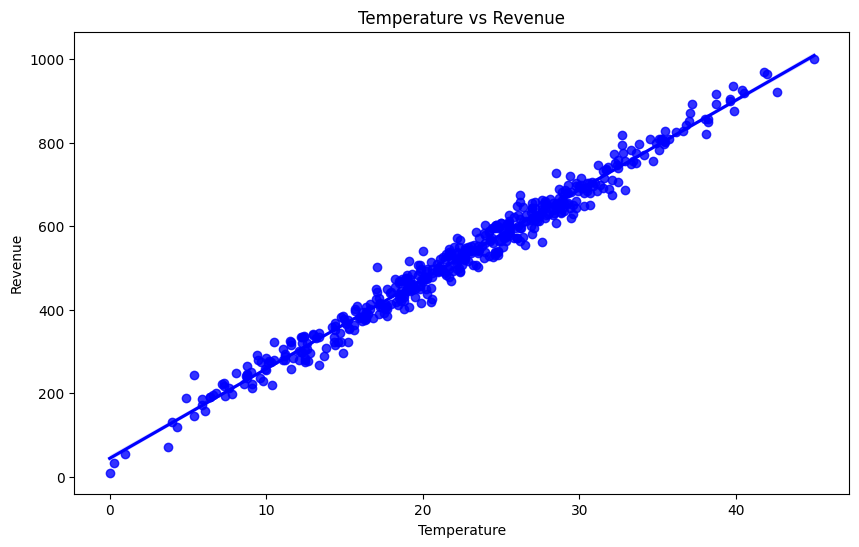

In [51]:

plt.figure(figsize=(10,6))
sns.regplot(data=icesales, x='Temperature', y='Revenue',color='blue')

plt.title('Temperature vs Revenue')
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.show()

# Based on the visualization, higher temperatures indicate higher sales revenue.

### Predicting New_Dataset

In [57]:
new_temperature = [[10], [20], [30], [40]]

In [58]:
# Creating new temperature data for prediction

new_temperature = pd.DataFrame({
    "Temperature": [10, 20, 30, 40]
})

In [59]:
# Predicting ice cream sales for the new temperature values

new_revenue = icesalesmodel.predict(new_temperature)

print(new_revenue)

[259.28023695 473.49694767 687.71365839 901.93036911]
